In [1]:
import numpy as np
import pandas as pd
import joblib
from scipy import sparse
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X_train = sparse.load_npz("../data/processed/X_train.npz")
X_test = sparse.load_npz("../data/processed/X_test.npz")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (7519, 438) | X_test: (2025, 438)


In [2]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,   # utilise tous les cœurs CPU disponibles
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [3]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE : {mse_rf:.4f}")
print(f"MAE : {mae_rf:.4f}")
print(f"R²  : {r2_rf:.4f}")

print("\n--- Comparaison avec Ridge (baseline) ---")
print(f"{'Métrique':<10}{'Ridge':<10}{'Random Forest':<15}")
print(f"{'MSE':<10}{0.0247:<10.4f}{mse_rf:<15.4f}")
print(f"{'MAE':<10}{0.1227:<10.4f}{mae_rf:<15.4f}")
print(f"{'R²':<10}{0.2067:<10.4f}{r2_rf:<15.4f}")

MSE : 0.0171
MAE : 0.0983
R²  : 0.4513

--- Comparaison avec Ridge (baseline) ---
Métrique  Ridge     Random Forest  
MSE       0.0247    0.0171         
MAE       0.1227    0.0983         
R²        0.2067    0.4513         


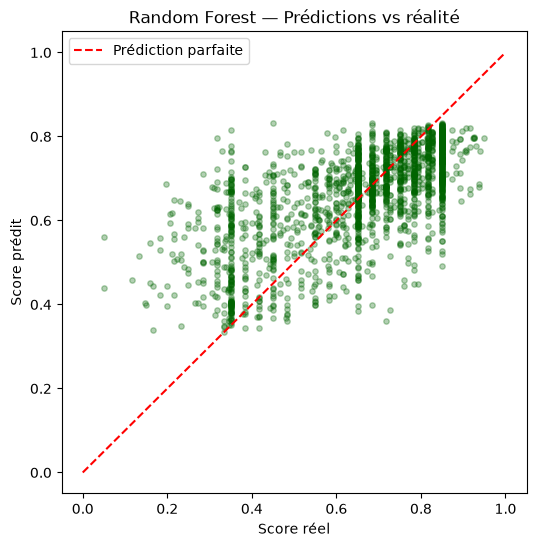

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=15, color="darkgreen")
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Prédiction parfaite")
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Random Forest — Prédictions vs réalité")
plt.legend()
plt.show()

In [5]:
tfidf = joblib.load("../data/processed/tfidf_vectorizer.pkl")
ohe = joblib.load("../data/processed/job_position_encoder.pkl")

numeric_cols = [
    "skills_overlap", "experience_years_min",
    "has_career_objective", "has_certifications", "has_languages",
    "has_extra_curricular", "has_skills_required",
    "has_experience_requirement", "has_age_requirement",
]

feature_names = (
    list(tfidf.get_feature_names_out())
    + list(tfidf.get_feature_names_out())
    + ["text_similarity"]
    + numeric_cols
    + list(ohe.get_feature_names_out())
)

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names[:len(rf_model.feature_importances_)]
)

print("Top 15 features les plus importantes (Random Forest) :")
print(importances.sort_values(ascending=False).head(15))

Top 15 features les plus importantes (Random Forest) :
autocad                 0.145580
text_similarity         0.132231
machine learning        0.060834
management              0.039042
has_age_requirement     0.032630
machine                 0.016493
bachelor                0.013821
data                    0.012373
business                0.011591
python                  0.011287
quality                 0.010655
has_career_objective    0.010568
learning                0.009487
accounting              0.009063
looking                 0.008576
dtype: float64


In [6]:
joblib.dump(rf_model, "../data/processed/random_forest_model.pkl")
print("Modèle Random Forest sauvegardé.")

Modèle Random Forest sauvegardé.
